# Stage 7 Homework — Outliers + Risk Assumptions
In this assignment you will implement outlier detection/handling and run a simple sensitivity analysis.

**Chain:** In the lecture, we learned detection (IQR, Z-score), options for handling (remove/winsorize), and sensitivity testing. Now, you will adapt those methods to a provided dataset and document the risks and assumptions behind your choices.

## Setup - Generate the Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset: business-day dates from 2022-01-03 to 2022-06-10, a `daily_return` column that sits slightly lower before May, five large shock values injected in May, and a second column `daily_return_2` correlated with the first. The dataset has NO missing values - filling those in was stage 06; this stage is about outliers. 
It saves the file under `data/raw/`; the load cell below reads back that same path from the `csv_path` variable, so the filename is written in exactly one place.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 53.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 57.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


In [3]:
import os
import numpy as np
import pandas as pd

# Define folder paths relative to this notebook
raw_dir = '../data/raw'
processed_dir = '../data/processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

Synthetic dataset with two columns created and saved to ../data/raw/outliers_homework.csv


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [4]:
data_path = Path(csv_path)   # the SAME variable the Setup cell saved to, so the filename is
                             # defined once, up there - renaming it there is enough
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Outlier Functions - Sample Implementations (required)

Both functions below already work. Your job is to **read them, improve them, and then use them** - not to retype them. Worth improving: they silently accept an empty series; they do not state what happens to `NaN`; `detect_outliers_zscore` uses the population standard deviation (`ddof=0`) without saying why; and neither checks that `k` or `threshold` is positive. Document whatever you change, and say in your reflection why it mattered.

In [5]:
def _validate_numeric_series(series: pd.Series) -> pd.Series:
    """Validate a Series used by the outlier utilities and return non-missing values.

    NaN values are excluded from threshold calculations. Detection functions below preserve
    the original index and mark NaN positions as False rather than treating missingness as
    an outlier.
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")
    if series.empty:
        raise ValueError("series must not be empty")
    if not pd.api.types.is_numeric_dtype(series):
        raise TypeError("series must contain numeric data")

    valid = series.dropna()
    if valid.empty:
        raise ValueError("series must contain at least one non-missing numeric value")
    return valid


def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Return a boolean mask for IQR-based outliers.

    An observation is flagged when it falls below Q1 - k*IQR or above Q3 + k*IQR.
    The default k=1.5 is the conventional Tukey rule. NaN values are ignored when
    estimating quartiles and are returned as False in the mask.

    Parameters
    ----------
    series : pd.Series
        Numeric observations.
    k : float, default 1.5
        Positive multiplier controlling the width of the IQR fences.

    Returns
    -------
    pd.Series
        Boolean Series aligned to the input index.
    """
    if not np.isfinite(k) or k <= 0:
        raise ValueError("k must be a positive finite number")

    valid = _validate_numeric_series(series)
    q1 = valid.quantile(0.25)
    q3 = valid.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr

    mask = pd.Series(False, index=series.index, dtype=bool)
    mask.loc[valid.index] = (valid < lower) | (valid > upper)
    return mask


def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return a boolean mask for observations with |z| > threshold.

    The mean and sample standard deviation (ddof=1) are estimated from non-missing
    observations. A threshold of 3.0 is a common rule when the distribution is roughly
    normal. If the valid observations have zero/undefined standard deviation, no values
    are flagged. NaN positions are returned as False.

    Parameters
    ----------
    series : pd.Series
        Numeric observations.
    threshold : float, default 3.0
        Positive absolute z-score cutoff.

    Returns
    -------
    pd.Series
        Boolean Series aligned to the input index.
    """
    if not np.isfinite(threshold) or threshold <= 0:
        raise ValueError("threshold must be a positive finite number")

    valid = _validate_numeric_series(series)
    mu = valid.mean()
    sigma = valid.std(ddof=1)

    mask = pd.Series(False, index=series.index, dtype=bool)
    if pd.isna(sigma) or np.isclose(sigma, 0.0):
        return mask

    z = (valid - mu) / sigma
    mask.loc[valid.index] = z.abs() > threshold
    return mask

*(Stretch)* A working `winsorize_series` is provided below. Improve it if you can - it does not check that `lower` is below `upper` - then use it in the comparison further down.

In [6]:
def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    valid = _validate_numeric_series(series)
    if not (0 <= lower < upper <= 1):
        raise ValueError("quantiles must satisfy 0 <= lower < upper <= 1")
    
    lo = valid.quantile(lower)
    hi = valid.quantile(upper)
    return series.clip(lower=lo, upper=hi)

## Apply Detection and Create Flags (choose a numeric column)

In [7]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
target_col = 'daily_return' if 'daily_return' in numeric_cols else numeric_cols[0]

df['outlier_iqr'] = detect_outliers_iqr(df[target_col], k=1.5)
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
flag_summary = pd.DataFrame({
    'count_flagged': [df['outlier_iqr'].sum(), df['outlier_z'].sum()],
    'fraction_flagged': [df['outlier_iqr'].mean(), df['outlier_z'].mean()]
}, index=['IQR (k=1.5)', 'Z-score (threshold=3.0)'])

print(f'Target column: {target_col}')
display(flag_summary)

# Inspect every row identified by at least one method.
cols_to_show = [c for c in ['date', target_col, 'daily_return_2', 'outlier_iqr', 'outlier_z'] if c in df.columns]
display(df.loc[df['outlier_iqr'] | df['outlier_z'], cols_to_show])

Target column: daily_return


,count_flagged,fraction_flagged
IQR (k=1.5),9,0.078261
Z-score (threshold=3.0),5,0.043478


,date,daily_return,daily_return_2,outlier_iqr,outlier_z
41,2022-03-01,0.031952,0.023944,True,False
63,2022-03-31,-0.031101,-0.020710,True,False
85,2022-05-02,0.174843,0.112930,True,True
86,2022-05-03,-0.168258,-0.095461,True,True
87,2022-05-04,-0.033999,-0.028415,True,False
89,2022-05-06,-0.196672,-0.115209,True,True
90,2022-05-09,0.212402,0.136536,True,True
92,2022-05-11,0.028711,0.017664,True,False
93,2022-05-12,-0.178729,-0.100548,True,True


### Visual Checks (boxplot / histogram)

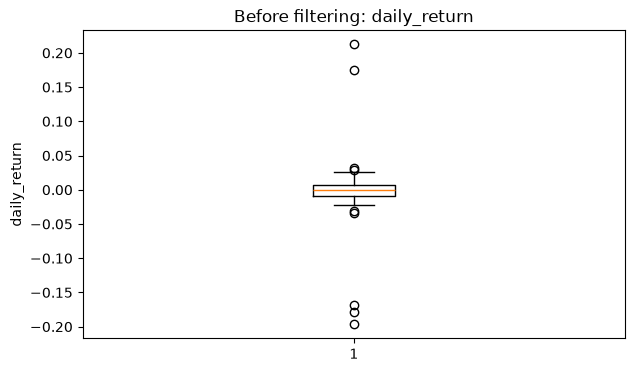

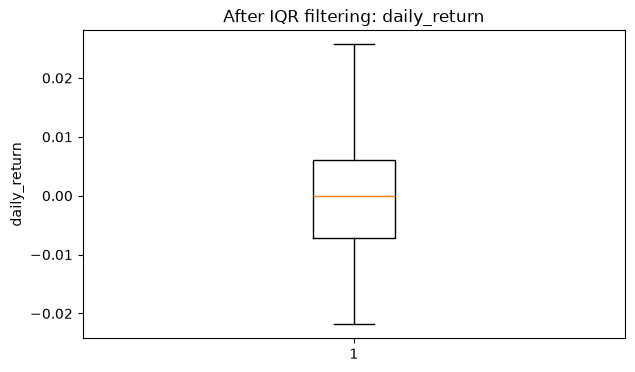

In [8]:
plt.figure(figsize=(7, 4))
plt.boxplot(df[target_col].dropna())
plt.title(f'Before filtering: {target_col}')
plt.ylabel(target_col)
plt.show()

filtered_values = df.loc[~df['outlier_iqr'], target_col].dropna()
plt.figure(figsize=(7, 4))
plt.boxplot(filtered_values)
plt.title(f'After IQR filtering: {target_col}')
plt.ylabel(target_col)
plt.show()

## Sensitivity Analysis
I use summary statistics as the primary sensitivity analysis and compare three treatments: **all observations**, **IQR-filtered observations**, and **5%/95% winsorized observations**. I also report a simple regression comparison as an additional check because the dataset contains two correlated numeric return columns.

In [10]:
# Option A: Primary sensitivity analysis: summary statistics
summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

keep_iqr = ~df['outlier_iqr']
summ_filtered = (
    df.loc[keep_iqr, target_col]
      .describe()[['mean', '50%', 'std']]
      .rename({'50%': 'median'})
)

keep_z = ~df['outlier_z']
summ_filtered_z = (
    df.loc[keep_z, target_col]
      .describe()[['mean', '50%', 'std']]
      .rename({'50%': 'median'})
)

winsorized = winsorize_series(df[target_col], lower=0.05, upper=0.95)
summ_winsorized = winsorized.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

summary_comparison = pd.concat(
    {
        'all': summ_all,
        'filtered_z': summ_filtered_z,
        'filtered_iqr': summ_filtered,
        'winsorized_5_95': summ_winsorized
    },
    axis=1
)

summary_comparison

,all,filtered_z,filtered_iqr,winsorized_5_95
mean,-0.001434,-0.000078,-0.000039,-0.000251
median,-0.000187,-0.000100,-0.000100,-0.000187
std,0.040579,0.011059,0.009443,0.010623


In [11]:
# Option B: Simple regression - did removing the outliers give us a BETTER model?

if 'daily_return_2' in df.columns and target_col != 'daily_return_2':
    resp_col = 'daily_return_2'
else:
    resp_col = [
        c for c in numeric_cols
        if c != target_col and not str(c).startswith('outlier_')
    ][0]

# Keep masks
keep_iqr = ~df['outlier_iqr']
keep_z = ~df['outlier_z']


# All data
X_all = df[[target_col]].to_numpy()
y_all = df[resp_col].to_numpy()


# IQR-filtered data
X_filtered_iqr = df.loc[keep_iqr, [target_col]].to_numpy()
y_filtered_iqr = df.loc[keep_iqr, resp_col].to_numpy()

# Z-score-filtered data
X_filtered_z = df.loc[keep_z, [target_col]].to_numpy()
y_filtered_z = df.loc[keep_z, resp_col].to_numpy()

# Fit models
model_all = LinearRegression().fit(X_all, y_all)

model_filtered_iqr = LinearRegression().fit(
    X_filtered_iqr,
    y_filtered_iqr
)

model_filtered_z = LinearRegression().fit(
    X_filtered_z,
    y_filtered_z
)

# Predictions
pred_all = model_all.predict(X_all)

pred_filtered_iqr = model_filtered_iqr.predict(
    X_filtered_iqr
)

pred_filtered_z = model_filtered_z.predict(
    X_filtered_z
)

# Compare regression results
regression_results = pd.DataFrame({
    'slope': [
        model_all.coef_[0],
        model_filtered_iqr.coef_[0],
        model_filtered_z.coef_[0]
    ],

    'intercept': [
        model_all.intercept_,
        model_filtered_iqr.intercept_,
        model_filtered_z.intercept_
    ],

    'r2': [
        r2_score(y_all, pred_all),
        r2_score(y_filtered_iqr, pred_filtered_iqr),
        r2_score(y_filtered_z, pred_filtered_z)
    ],

    'mae': [
        mean_absolute_error(y_all, pred_all),
        mean_absolute_error(y_filtered_iqr, pred_filtered_iqr),
        mean_absolute_error(y_filtered_z, pred_filtered_z)
    ],

    'n': [
        len(y_all),
        len(y_filtered_iqr),
        len(y_filtered_z)
    ]

}, index=[
    'all',
    'filtered_iqr',
    'filtered_z'
])

print(f'Regression: {resp_col} ~ {target_col}')
regression_results

Regression: daily_return_2 ~ daily_return


,slope,intercept,r2,mae,n
all,0.605869,0.000201,0.961859,0.003951,115
filtered_iqr,0.589679,-0.000049,0.573566,0.003851,106
filtered_z,0.630315,-0.000088,0.679331,0.003848,110


### Reflection (≤ 1 page)

For outlier detection, I used both the IQR method with (k=1.5) and the Z-score method with a threshold of 3.0. These are commonly used default thresholds and provide two different ways of defining extreme observations. The IQR method is based on quartiles and is relatively robust to extreme values, while the Z-score method measures how far an observation is from the mean in terms of standard deviations and therefore relies more strongly on the assumption that the data are approximately normally distributed. I also used 5%/95% winsorization as an alternative treatment because it reduces the influence of extreme observations without removing them entirely.

The two detection methods produced different results. IQR identified 9 outliers, while Z-score identified only 5. The five observations identified by Z-score were also identified by IQR, while IQR additionally classified four moderately extreme observations as outliers. This shows that the choice of method and threshold can materially affect which observations are treated as unusual. In this dataset, IQR was more aggressive than the 3.0 Z-score threshold.

The sensitivity analysis shows that extreme observations have a large effect on the estimated variability of `daily_return`. Using all observations, the standard deviation was 0.04058. After Z-score filtering, it decreased to 0.01106, and after IQR filtering it decreased further to 0.00944. The winsorized result, 0.01062, was between the two filtered cases. In contrast, the median changed very little across treatments, indicating that it is much less sensitive to extreme values than the mean or standard deviation.

The regression results also show why removing outliers is not automatically an improvement. With all 115 observations, the model had an (R^2) of 0.9619 and an MAE of 0.00395. After Z-score filtering, (R^2) decreased to 0.6793, and after IQR filtering it decreased further to 0.5736, although MAE improved slightly in both cases. The slope remained relatively close to 0.6 across all three models. This suggests that many of the extreme observations still follow the underlying relationship between `daily_return` and `daily_return_2`. Removing them reduces the range of the data and weakens the apparent explanatory power of the regression rather than clearly producing a better model.

The main risk is assuming that every statistical outlier represents an error or irrelevant observation. For financial return data, large movements may represent genuine market shocks rather than bad data. Removing such observations could underestimate risk and volatility and could discard economically meaningful information. Conversely, keeping erroneous extreme values could distort summary statistics and model estimates. Therefore, outlier treatment should depend not only on a statistical rule but also on the context of the data and the purpose of the analysis.


*Write your reflection here...*